In [1]:
import numpy as np
import torch
from torch.utils.data import DataLoader
import random
import pandas as pd
import pickle

from matrix_processing_helpers import sparsify_global_percentile

from models_transformer_embedding import SingleOutTransformerNet

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

test_data = np.load("data_processed/test_data_scaled.npz")
X_test = test_data["x"]    
y_test = test_data["age"]    
test_loader = DataLoader(X_test, batch_size=32, shuffle=False)

In [3]:
IN_DIM = X_test.shape[1]

EMB_DIM = 64
NHEAD = 4
NUM_LAYERS = 20
FF_DIM = 128
DROPOUT = 0.1

model = SingleOutTransformerNet(IN_DIM, emb_dim=EMB_DIM, nhead=NHEAD, 
                                num_layers=NUM_LAYERS, ff_dim=FF_DIM, 
                                dropout=DROPOUT).to(DEVICE)

state_dict = torch.load(f"trained_models/TR_model_{NUM_LAYERS}layers.pt")
model.load_state_dict(state_dict)

<All keys matched successfully>

In [4]:
def collect_hidden_states(model, test_loader, device):
    model.eval()
    all_hidden = []

    with torch.no_grad():
        for batch in test_loader:
            if isinstance(batch, (list, tuple)):
                x = batch[0]
            else:
                x = batch

            x = x.to(device)

            y, hidden_layers = model(x, return_hidden=True)

            # hidden_layers is a list:
            # [tokenizer output, layer 1 output, ..., layer L output, final norm output]
            hidden = torch.stack(hidden_layers, dim=0)
            # shape: [n_layers + 2, B, n_features, emb_dim]

            all_hidden.append(hidden.cpu().numpy())

    Z_layers = np.concatenate(all_hidden, axis=1)
    return Z_layers

In [5]:
Z_layers = collect_hidden_states(model, test_loader, DEVICE)

In [6]:
scores_df = pd.read_csv(f"Results/attention_scores/attention_scores{NUM_LAYERS}layers.csv")
# scores = scores_df["score"].to_numpy()
rollouts = np.load(f"Results/rollout_global/rollout{NUM_LAYERS}layers.npz")
rollout_matrix = sparsify_global_percentile(rollouts['rollout'], q=60, keep_diagonal=True)
scores = rollout_matrix.sum(axis=0)
feature_names = scores_df["feature"].to_numpy()



# top_idx, top_names, trajectories = get_topk_feature_trajectories(
#     Z_layers=Z_layers,
#     rollout_scores=scores,
#     feature_names=feature_names,
#     k=72,
# )

# print(top_names)

In [7]:
with open(f"Results/rollout_local/attn_matrices{NUM_LAYERS}layers.pkl", "rb") as f:
    attn_weights = pickle.load(f)

In [20]:
import numpy as np
import matplotlib.pyplot as plt

def identify_last_layer_leaders(attn_weights, feature_names, top_k=4):
    layer_keys = sorted(attn_weights.keys(), key=lambda s: int(s.split("_")[-1]))
    last_key = layer_keys[-1]

    A_last = attn_weights[last_key]['attn_matrix']          # [n_data, d, d]

    # Column score at last layer:
    # how much all features attend to each feature-column
    last_col_score = A_last.sum(axis=1).mean(axis=0)  # [d]

    # Normalize for readability
    last_col_score = last_col_score / last_col_score.sum()

    leader_idx = np.argsort(last_col_score)[-top_k:][::-1]
    leader_names = [feature_names[i] for i in leader_idx]
    print(leader_names)

    return leader_idx, leader_names, last_col_score

In [21]:
def plot_last_layer_leader_evolution(
    attn_weights,
    feature_names,
    top_k=4,
    title="Evolution of last-layer leader columns",
):
    layer_keys = sorted(attn_weights.keys(), key=lambda s: int(s.split("_")[-1]))

    # 1. Identify leaders from last layer only
    leader_idx, leader_names, last_col_score = identify_last_layer_leaders(
        attn_weights,
        feature_names,
        top_k=top_k,
    )

    # 2. Compute their column scores across all layers
    all_scores = []

    for key in layer_keys:
        A = attn_weights[key]['attn_matrix']  # [n_data, d, d]

        col_score = A.sum(axis=1).mean(axis=0)
        col_score = col_score / col_score.sum()

        all_scores.append(col_score)

    all_scores = np.stack(all_scores, axis=0)  # [num_layers, d]

    # 3. Plot only the leaders selected from the final layer
    layers = np.arange(1, len(layer_keys) + 1)

    plt.figure(figsize=(8, 5))

    for idx, name in zip(leader_idx, leader_names):
        plt.plot(
            layers,
            all_scores[:, idx],
            marker="o",
            linewidth=2,
            label=name,
        )

    plt.xlabel("Attention layer")
    plt.ylabel("Normalized column score")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return leader_idx, leader_names, all_scores, last_col_score

['GlycB to GlycA ratio (unitless)', 'Triglycerides (mg/dl)', 'Aspartate (mM)', 'Methionine (mM)']


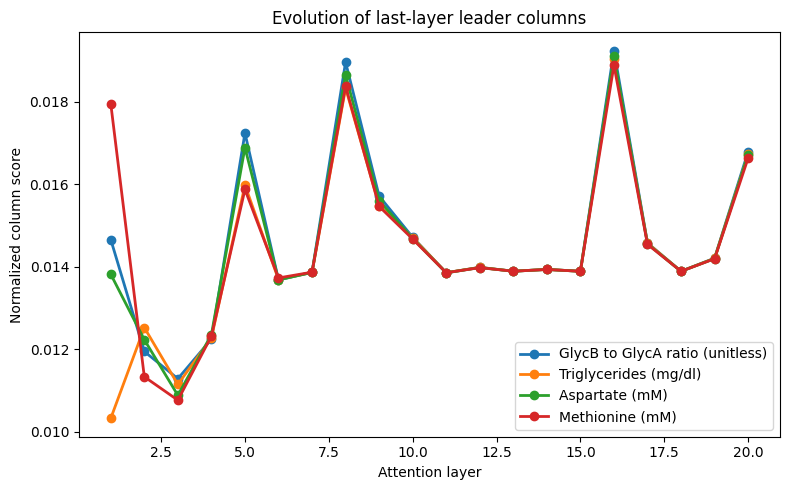

Last-layer leaders:
19 GlycB to GlycA ratio (unitless) 0.016790744
58 Triglycerides (mg/dl) 0.016722409
65 Aspartate (mM) 0.01671864
69 Methionine (mM) 0.016634883


In [22]:
leader_idx, leader_names, all_scores, last_col_score = plot_last_layer_leader_evolution(
    attn_weights=attn_weights,
    feature_names=feature_names,
    top_k=4,
)

print("Last-layer leaders:")
for i, name in zip(leader_idx, leader_names):
    print(i, name, last_col_score[i])